In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [5]:
train = pd.read_csv('../dataset/train.csv')
test = pd.read_csv('../dataset/test.csv')
print("Train shape:", train.shape)
print(train.head())
print(train.dtypes)

Train shape: (77299, 11)
   Index geohash  day timestamp    demand     RoadType  NumberofLanes  \
0      0  qp02z1   48       0:0  0.048804          NaN              1   
1      1  qp02zt   48       0:0  0.118507  Residential              3   
2      2  qp08bj   48       0:0  0.027132  Residential              1   
3      3  qp08gt   48       0:0  0.003272  Residential              1   
4      4  qp02zq   48       0:0  0.010819  Residential              1   

  LargeVehicles Landmarks  Temperature Weather  
0   Not Allowed        No          NaN     NaN  
1       Allowed       Yes    31.104565   Sunny  
2   Not Allowed        No    25.919267   Sunny  
3   Not Allowed        No          NaN   Rainy  
4   Not Allowed        No    10.803667   Rainy  
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      

In [50]:
train['RoadType'] = train['RoadType'].fillna(train['RoadType'].mode()[0])
train['Temperature'] = train['Temperature'].fillna(train['Temperature'].median())
train['Weather'] = train['Weather'].fillna(train['Weather'].mode()[0])
test['RoadType'] = test['RoadType'].fillna(test['RoadType'].mode()[0])
test['Temperature'] = test['Temperature'].fillna(test['Temperature'].median())
test['Weather'] = test['Weather'].fillna(test['Weather'].mode()[0])
print("Missing after cleanup:")
print(train.isnull().sum())

Missing after cleanup:
Index                     0
geohash                   0
day                       0
timestamp                 0
demand                    0
RoadType                  0
NumberofLanes             0
LargeVehicles             0
Landmarks                 0
Temperature               0
Weather                   0
hour                      0
weekday                   0
is_weekend                0
is_peak_hour              0
rush_hour                 0
hour_sin                  0
hour_cos                  0
large_vehicles_allowed    0
vehicle_per_lane          0
has_landmark              0
road_type_enc             0
weather_enc               0
geohash_target_enc        0
geo_prefix                0
geo_prefix_enc            0
demand_log                0
dtype: int64


In [51]:
train['hour'] = train['timestamp'].apply(lambda x: int(str(x).split(':')[0]))
test['hour'] = test['timestamp'].apply(lambda x: int(str(x).split(':')[0]))
print(train[['timestamp', 'hour']].head(10))

  timestamp  hour
0       0:0     0
1       0:0     0
2       0:0     0
3       0:0     0
4       0:0     0
5       0:0     0
6       0:0     0
7       0:0     0
8       0:0     0
9       0:0     0


In [52]:

train['weekday'] = train['day'] % 7
train['is_weekend'] = train['weekday'].apply(lambda x: 1 if x >= 5 else 0)
train['is_peak_hour'] = train['hour'].apply(lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0)
train['rush_hour'] = train['hour'].apply(lambda x: 1 if (8 <= x <= 9) or (18 <= x <= 19) else 0)
test['weekday'] = test['day'] % 7
test['is_weekend'] = test['weekday'].apply(lambda x: 1 if x >= 5 else 0)
test['is_peak_hour'] = test['hour'].apply(lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0)
test['rush_hour'] = test['hour'].apply(lambda x: 1 if (8 <= x <= 9) or (18 <= x <= 19) else 0)

print(train[['hour', 'weekday', 'is_weekend', 'is_peak_hour', 'rush_hour']].head(10))

   hour  weekday  is_weekend  is_peak_hour  rush_hour
0     0        6           1             0          0
1     0        6           1             0          0
2     0        6           1             0          0
3     0        6           1             0          0
4     0        6           1             0          0
5     0        6           1             0          0
6     0        6           1             0          0
7     0        6           1             0          0
8     0        6           1             0          0
9     0        6           1             0          0


In [53]:
train['hour_sin'] = np.sin(2 * np.pi * train['hour'] / 24)
train['hour_cos'] = np.cos(2 * np.pi * train['hour'] / 24)
test['hour_sin'] = np.sin(2 * np.pi * test['hour'] / 24)
test['hour_cos'] = np.cos(2 * np.pi * test['hour'] / 24)
print(train[['hour', 'hour_sin', 'hour_cos']].drop_duplicates().sort_values('hour'))

       hour      hour_sin      hour_cos
0         0  0.000000e+00  1.000000e+00
2911      1  2.588190e-01  9.659258e-01
6239      2  5.000000e-01  8.660254e-01
9792      3  7.071068e-01  7.071068e-01
13387     4  8.660254e-01  5.000000e-01
17070     5  9.659258e-01  2.588190e-01
20691     6  1.000000e+00  6.123234e-17
24356     7  9.659258e-01 -2.588190e-01
27925     8  8.660254e-01 -5.000000e-01
31432     9  7.071068e-01 -7.071068e-01
34981    10  5.000000e-01 -8.660254e-01
38603    11  2.588190e-01 -9.659258e-01
42170    12  1.224647e-16 -1.000000e+00
45695    13 -2.588190e-01 -9.659258e-01
48966    14 -5.000000e-01 -8.660254e-01
51966    15 -7.071068e-01 -7.071068e-01
54546    16 -8.660254e-01 -5.000000e-01
56654    17 -9.659258e-01 -2.588190e-01
58338    18 -1.000000e+00 -1.836970e-16
59585    19 -9.659258e-01  2.588190e-01
60799    20 -8.660254e-01  5.000000e-01
62217    21 -7.071068e-01  7.071068e-01
63955    22 -5.000000e-01  8.660254e-01
66365    23 -2.588190e-01  9.659258e-01


In [55]:
train['large_vehicles_allowed'] = train['LargeVehicles'].apply(lambda x: 1 if x == 'Allowed' else 0)
train['vehicle_per_lane'] = train['large_vehicles_allowed'] / train['NumberofLanes'].replace(0, 1)

test['large_vehicles_allowed'] = test['LargeVehicles'].apply(lambda x: 1 if x == 'Allowed' else 0)
test['vehicle_per_lane'] = test['large_vehicles_allowed'] / test['NumberofLanes'].replace(0, 1)
print(train[['LargeVehicles', 'large_vehicles_allowed', 'NumberofLanes', 'vehicle_per_lane']].head())

  LargeVehicles  large_vehicles_allowed  NumberofLanes  vehicle_per_lane
0   Not Allowed                       0              1          0.000000
1       Allowed                       1              3          0.333333
2   Not Allowed                       0              1          0.000000
3   Not Allowed                       0              1          0.000000
4   Not Allowed                       0              1          0.000000


In [59]:
train['has_landmark'] = train['Landmarks'].apply(lambda x: 1 if x == 'Yes' else 0)

road_type_map = {v: i for i, v in enumerate(train['RoadType'].unique())}
train['road_type_enc'] = train['RoadType'].map(road_type_map)

weather_map = {v: i for i, v in enumerate(train['Weather'].unique())}
train['weather_enc'] = train['Weather'].map(weather_map)

test['has_landmark'] = test['Landmarks'].apply(lambda x: 1 if x == 'Yes' else 0)

road_type_map_test = {v: i for i, v in enumerate(test['RoadType'].unique())}
test['road_type_enc'] = test['RoadType'].map(road_type_map)

weather_map_test = {v: i for i, v in enumerate(test['Weather'].unique())}
test['weather_enc'] = test['Weather'].map(weather_map)

print("RoadType map:", road_type_map)
print("Weather map:", weather_map)

RoadType map: {'Residential': 0, 'Street': 1, 'Highway': 2}
Weather map: {'Sunny': 0, 'Rainy': 1, 'Foggy': 2, 'Snowy': 3}


In [64]:
geo_mean = train.groupby('geohash')['demand'].mean()
train['geohash_target_enc'] = train['geohash'].map(geo_mean)

train['geo_prefix'] = train['geohash'].str[:4]
geo_prefix_mean = train.groupby('geo_prefix')['demand'].mean()
train['geo_prefix_enc'] = train['geo_prefix'].map(geo_prefix_mean)

print(train[['geohash', 'geohash_target_enc', 'geo_prefix_enc']].head())

  geohash  geohash_target_enc  geo_prefix_enc
0  qp02z1            0.040048        0.139909
1  qp02zt            0.208766        0.139909
2  qp08bj            0.127931        0.056277
3  qp08gt            0.014381        0.056277
4  qp02zq            0.029300        0.139909


Demand skewness: 3.729


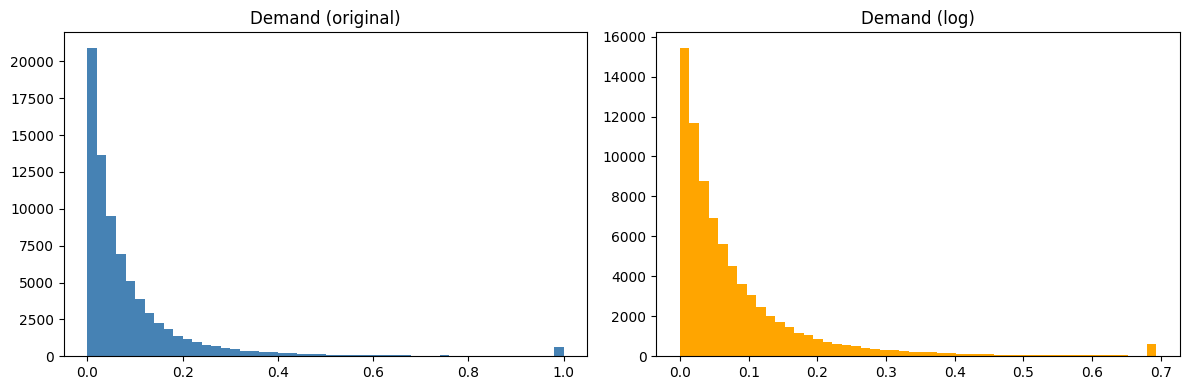

In [13]:
print("Demand skewness:", round(train['demand'].skew(), 3))
train['demand_log'] = np.log1p(train['demand'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['demand'], bins=50, color='steelblue')
axes[0].set_title('Demand (original)')
axes[1].hist(train['demand_log'], bins=50, color='orange')
axes[1].set_title('Demand (log)')
plt.tight_layout()
plt.show()

In [65]:
feature_cols = [
    'hour', 'hour_sin', 'hour_cos',
    'is_weekend', 'is_peak_hour', 'rush_hour', 'weekday',
    'NumberofLanes', 'road_type_enc',
    'large_vehicles_allowed', 'vehicle_per_lane',
    'has_landmark',
    'Temperature', 'weather_enc'
]

target_col = 'demand'

train_final = train[feature_cols + [target_col]].copy()
test_final=test[feature_cols].copy()
print("Final shape:", train_final.shape)
print("Missing values:", train_final.isnull().sum().sum())

train_final.to_csv('train_fe.csv', index=False)
print("Saved!")

Final shape: (77299, 15)
Missing values: 0
Saved!


In [66]:
X_test= test[feature_cols]
X_test = X_test.fillna(X_test.median(numeric_only=True))

In [67]:
X = train_final.drop(['demand'], axis=1)
y = train_final['demand']
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=35)
model.fit(X_train, y_train)
ytest_pred = model.predict(X_val)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Training predictions
ytrain_pred = model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, ytrain_pred))
test_rmse = np.sqrt(mean_squared_error(y_val, ytest_pred))

train_r2 = r2_score(y_train, ytrain_pred)
test_r2 = r2_score(y_val, ytest_pred)

print("Train RMSE:", train_rmse)
print("Test RMSE :", test_rmse)
print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

Train RMSE: 0.0421853006064702
Test RMSE : 0.08309696700457564
Train R2 : 0.911960328663629
Test R2  : 0.6587455547992702


In [ ]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from catboost import CatBoostRegressor
from sklearn import metrics
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=10,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f'CV R² scores : {cv_scores.round(4)}')
print(f'Mean CV R²   : {cv_scores.mean():.4f}')
print(f'Contest score: {max(0, 100 * cv_scores.mean()):.2f}')
model.fit(
    X,
    y,
    cat_features=feature_cols,
    eval_set=(X, y),
    early_stopping_rounds=200,
    verbose=100
)

preds= model.predict(X)

train_r2 = metrics.r2_score(y, preds)
print(f'Train R² (in-sample): {train_r2:.4f}')

0:	learn: 0.0439968	total: 25.4ms	remaining: 50.8s
100:	learn: 0.7670170	total: 2.04s	remaining: 38.4s
200:	learn: 0.7784370	total: 5.46s	remaining: 48.9s
300:	learn: 0.7855268	total: 9.22s	remaining: 52.1s
400:	learn: 0.7909776	total: 14s	remaining: 55.9s
500:	learn: 0.7962426	total: 29.5s	remaining: 1m 28s
600:	learn: 0.8007925	total: 45.6s	remaining: 1m 46s
700:	learn: 0.8047683	total: 52s	remaining: 1m 36s
800:	learn: 0.8082706	total: 1m 5s	remaining: 1m 38s
900:	learn: 0.8115644	total: 1m 15s	remaining: 1m 31s


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=100,
    random_state=42
)

model.fit(Xtrain, ytrain)

ytest_pred = model.predict(Xtest)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Training predictions
ytrain_pred = model.predict(Xtrain)

train_rmse = np.sqrt(mean_squared_error(ytrain, ytrain_pred))
test_rmse = np.sqrt(mean_squared_error(ytest, ytest_pred))

train_r2 = r2_score(ytrain, ytrain_pred)
test_r2 = r2_score(ytest, ytest_pred)

print("Train RMSE:", train_rmse)
print("Test RMSE :", test_rmse)
print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

In [ ]:
# y_pred = train_final.predict(X_test)

# submission = pd.DataFrame({
#     'Index' : test['Index'].values,
#     'demand': y_pred
# })

# submission.to_csv('a.csv', index=False)
# print('Saved submission.csv')
# print(submission.head())
# print('Shape:', submission.shape) 

In [ ]:
importance = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
importance = importance.sort_values(ascending=False)
print('\nTop features:')
print(importance.head(10).round(4))